In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import imblearn
from imblearn.over_sampling import SMOTE
from collections import Counter

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

from sklearn.neighbors import  KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, confusion_matrix
import pickle

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [ ]:
import pandas as pd

# Login using e.g. `huggingface-cli login` to access this dataset
df = pd.read_csv("hf://datasets/Jakehills/Crop_Yield_Fertilizer/Crop_Yield_Fertilizer.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,yield,fertilizer
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,rice,71.199428,DAP
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,rice,81.620199,DAP
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,rice,80.473130,Gypsum
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,rice,75.178196,DAP
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,rice,75.485563,Gypsum


In [ ]:
import joblib
from sklearn.preprocessing import LabelEncoder

label_encoder=LabelEncoder()
df['label']=label_encoder.fit_transform(df['label'])

# Create fertname_dict from the label_encoder
fertname_dict_new = {}
for i in range(len(label_encoder.classes_)):
    fertname_dict_new[i] = label_encoder.inverse_transform([i])[0]

# Save the new fertname_dict.pkl
joblib.dump(fertname_dict_new, "fertname_dict.pkl")
print("New fertname_dict.pkl saved successfully!")

fert_encoder=LabelEncoder()
df['fertilizer']=fert_encoder.fit_transform(df['fertilizer'])

New fertname_dict.pkl saved successfully!


In [ ]:
X=df[df.columns[:-1]].drop(['yield'],axis=1)
y=df[df.columns[-1]]

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
xgb_pipeline = make_pipeline(StandardScaler(), XGBClassifier(random_state = 18))
xgb_pipeline.fit(x_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

Accuracy on Test Data: 95.5%


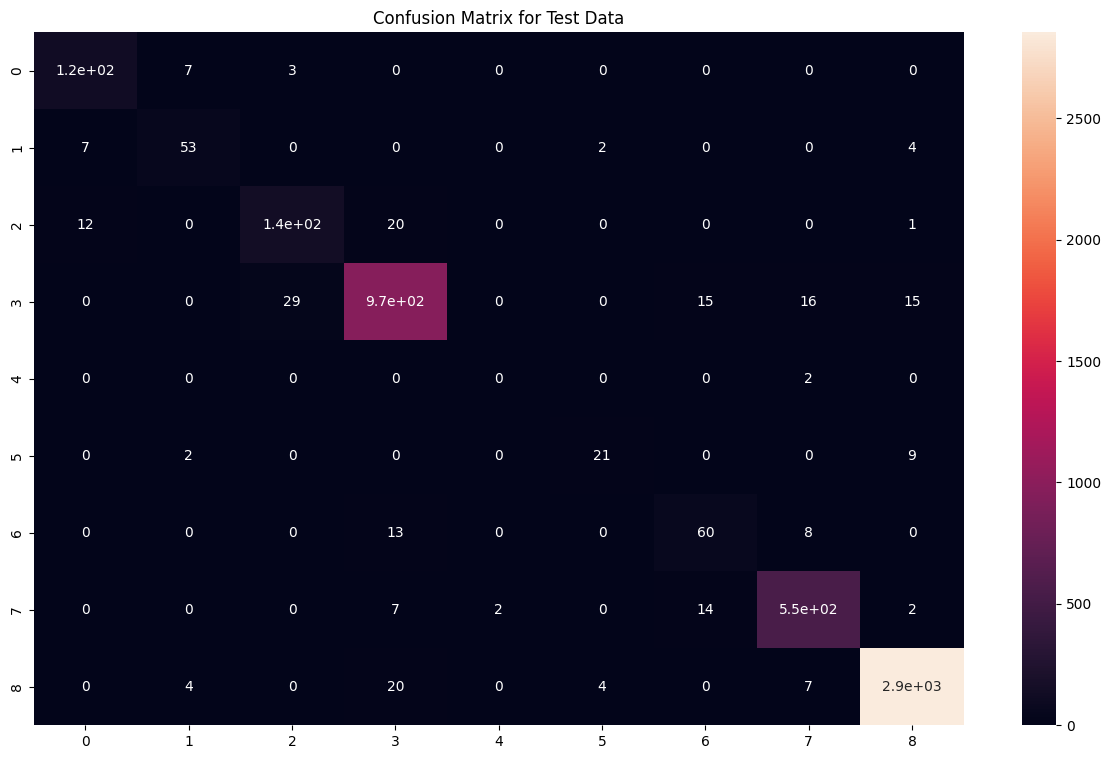


Accuracy on Whole Data: 99.1%


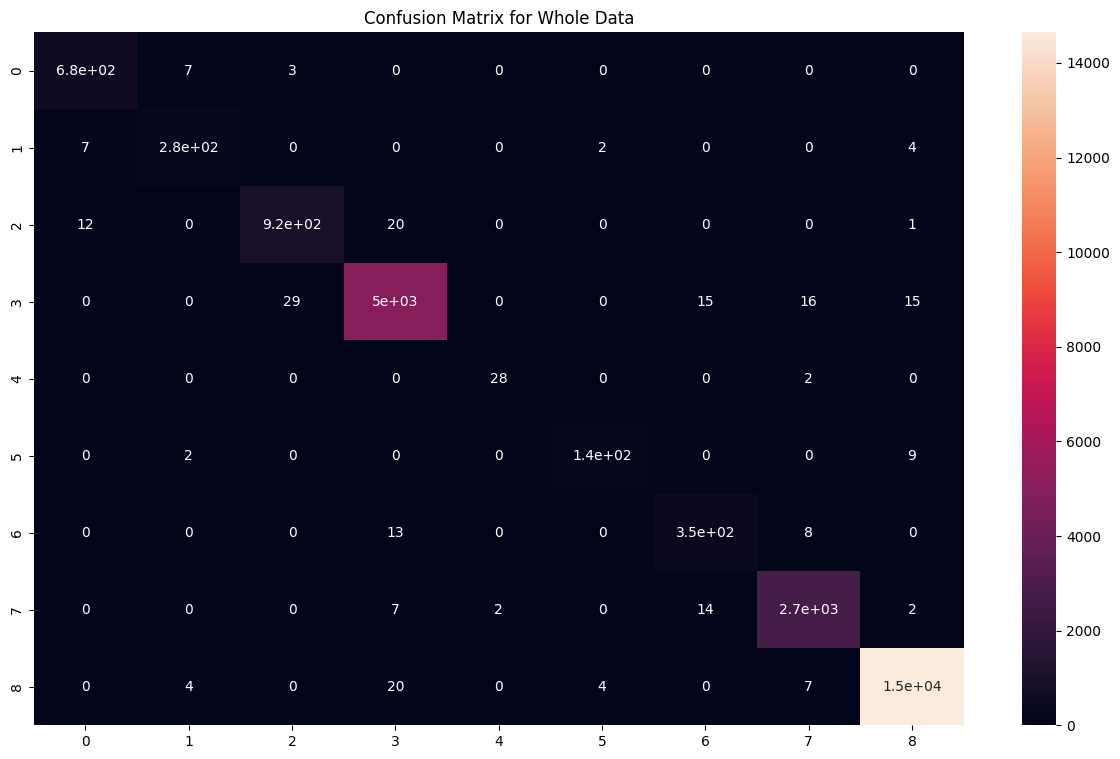

In [ ]:
xgb_pipeline = make_pipeline(StandardScaler(), XGBClassifier(random_state = 18))
xgb_pipeline.fit(x_train, y_train)

# Accuray On Test Data
predictions = xgb_pipeline.predict(x_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy on Test Data: {accuracy*100}%")
plt.figure(figsize = (15,9))
sns.heatmap(confusion_matrix(y_test, predictions), annot = True)
plt.title("Confusion Matrix for Test Data")
plt.show()

print()

# Accuray On Whole Data
predictions = xgb_pipeline.predict(X.values)
accuracy = accuracy_score(y, predictions)
print(f"Accuracy on Whole Data: {accuracy*100}%")
plt.figure(figsize = (15,9))
sns.heatmap(confusion_matrix(y, predictions), annot = True)
plt.title("Confusion Matrix for Whole Data")
plt.show()

In [ ]:
X1 = df2[df2.columns[:-1]]
y2 = df2[df2.columns[-1]]

In [ ]:
import joblib

joblib.dump(xgb_pipeline, "xgb_pipeline.pkl")

In [ ]:
from google.colab import files
files.download("fertname_dict.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib
import numpy as np

xgb_pipeline_loaded = joblib.load("xgb_pipeline.pkl")
fertname_dict_loaded = joblib.load("fertname_dict.pkl")

In [ ]:
import joblib
import numpy as np

xgb_pipeline_loaded = joblib.load("xgb_pipeline.pkl")
fertname_dict_loaded = joblib.load("fertname_dict.pkl")

print("XGBoost model and fertilizer dictionary loaded successfully!")

XGBoost model and fertilizer dictionary loaded successfully!


In [ ]:
import joblib

joblib.dump(xgb_pipeline, "xgb_pipeline.pkl")

['xgb_pipeline.pkl']

In [ ]:
import joblib
import numpy as np

# Load the saved models and dictionaries
xgb_pipeline_loaded = joblib.load("xgb_pipeline.pkl")
fertname_dict_loaded = joblib.load("fertname_dict.pkl")
croptype_dict_loaded = joblib.load("croptype_dict.pkl")
soiltype_dict_loaded = joblib.load("soiltype_dict.pkl")

print("XGBoost model and dictionaries loaded successfully!")